In [12]:
#Import Packages
import xarray as xr
print("Successfully imported xarray")

import matplotlib.pyplot as plt
print("Successfully imported matplotlib")

import numpy as np
print("Successfully imported numpy")

import pandas as pd
print("Successfully imported pandas")

import seaborn as sns
print("Successfully imported seaborn")

import cdsapi
print("Successfully imported cdsapi")

import cartopy.crs as ccrs
print("Successfully imported cartopy.crs")

import cartopy.feature as cfeature
print("Successfully imported cartopy.feature")

Successfully imported xarray
Successfully imported matplotlib
Successfully imported numpy
Successfully imported pandas
Successfully imported seaborn
Successfully imported cdsapi
Successfully imported cartopy.crs
Successfully imported cartopy.feature


In [11]:
import pandas as pd

df = pd.read_csv("suriname_all_vars_2004_2023.csv")  # adjust filename to match what you downloaded
print(df.columns.tolist())
print(df.head())

['system:index', 'convective_precipitation', 'date', 'surface_solar_radiation_downwards', 'total_cloud_cover', 'total_precipitation', '.geo']
   system:index  convective_precipitation        date  \
0             0                  0.015942  2004-01-01   
1             1                  0.003057  2004-01-02   
2             2                  0.003471  2004-01-03   
3             3                  0.012302  2004-01-04   
4             4                  0.005708  2004-01-05   

   surface_solar_radiation_downwards  total_cloud_cover  total_precipitation  \
0                       1.164286e+07           0.988459             0.018975   
1                       1.808253e+07           0.686220             0.004087   
2                       1.784671e+07           0.432867             0.004840   
3                       1.319494e+07           0.824493             0.014700   
4                       1.684875e+07           0.860476             0.007772   

                                  

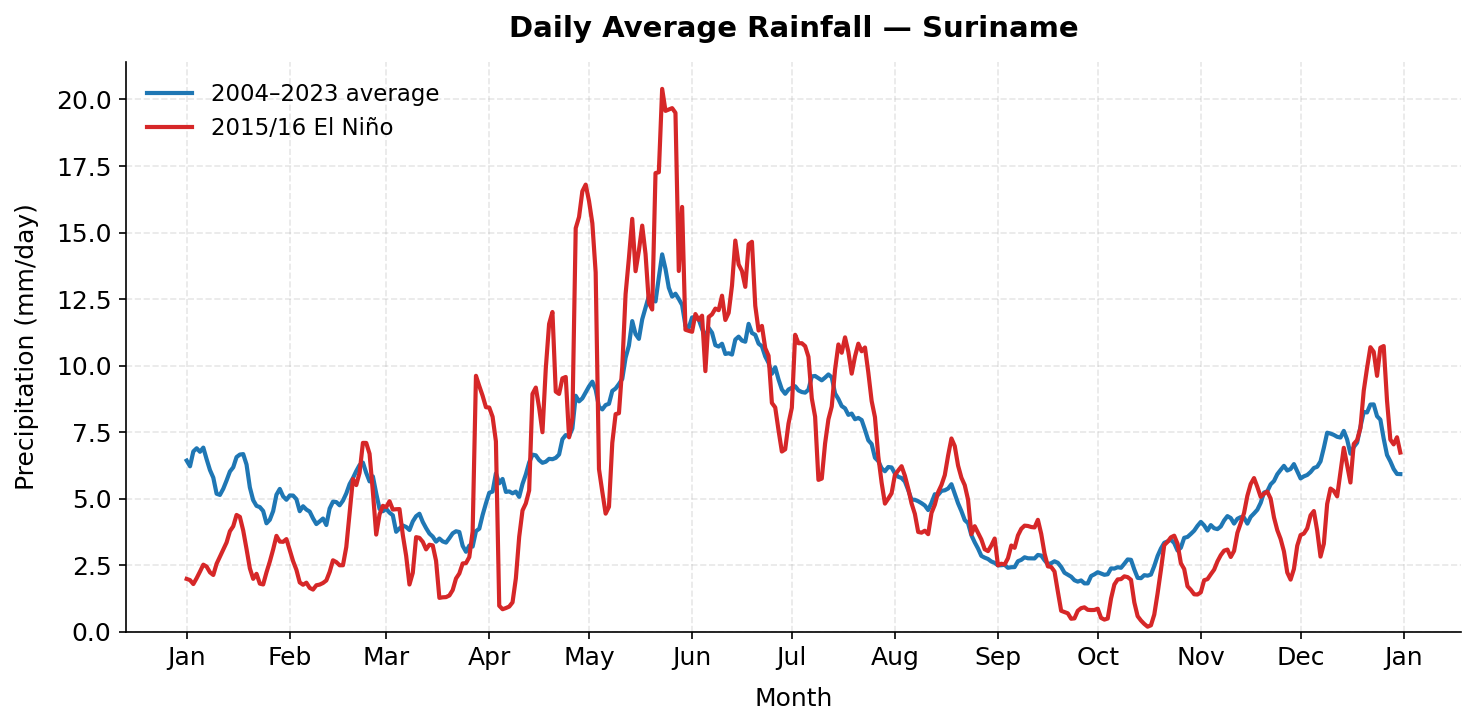

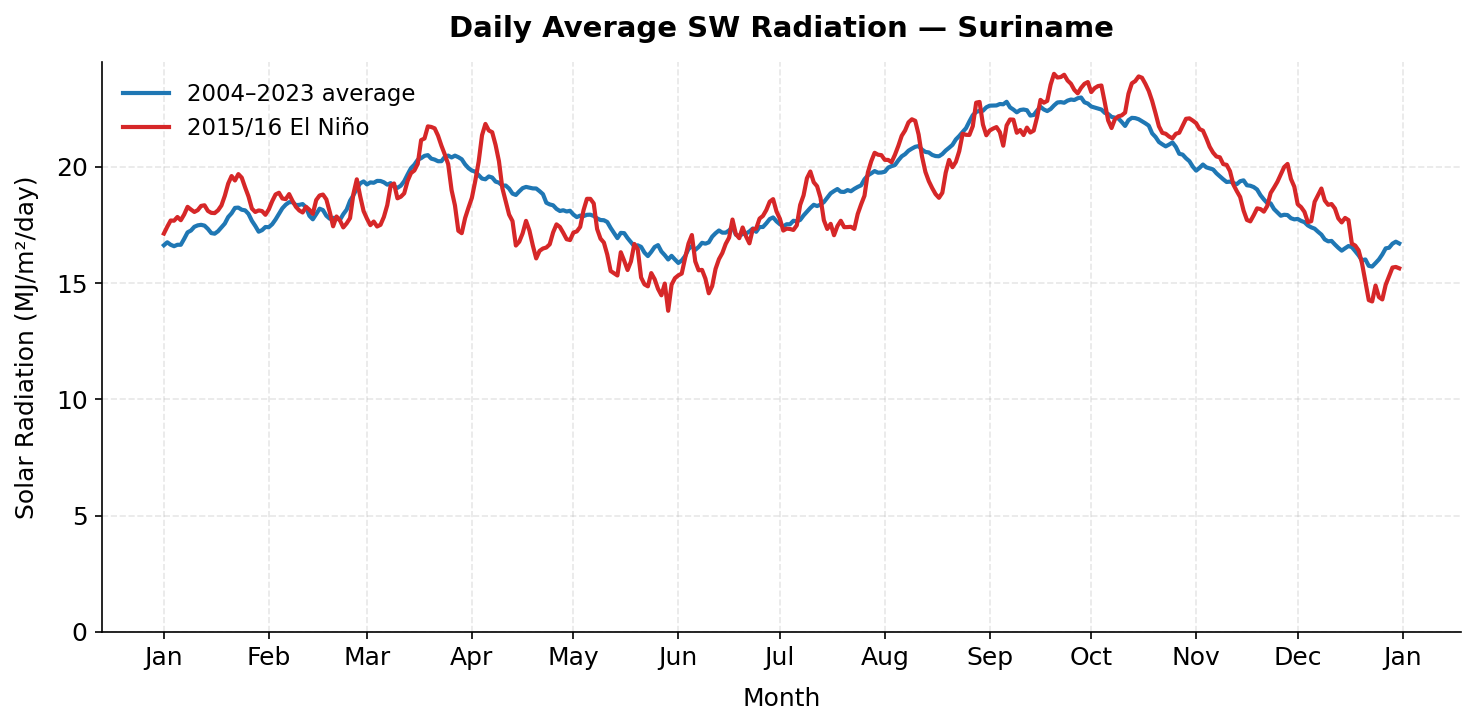

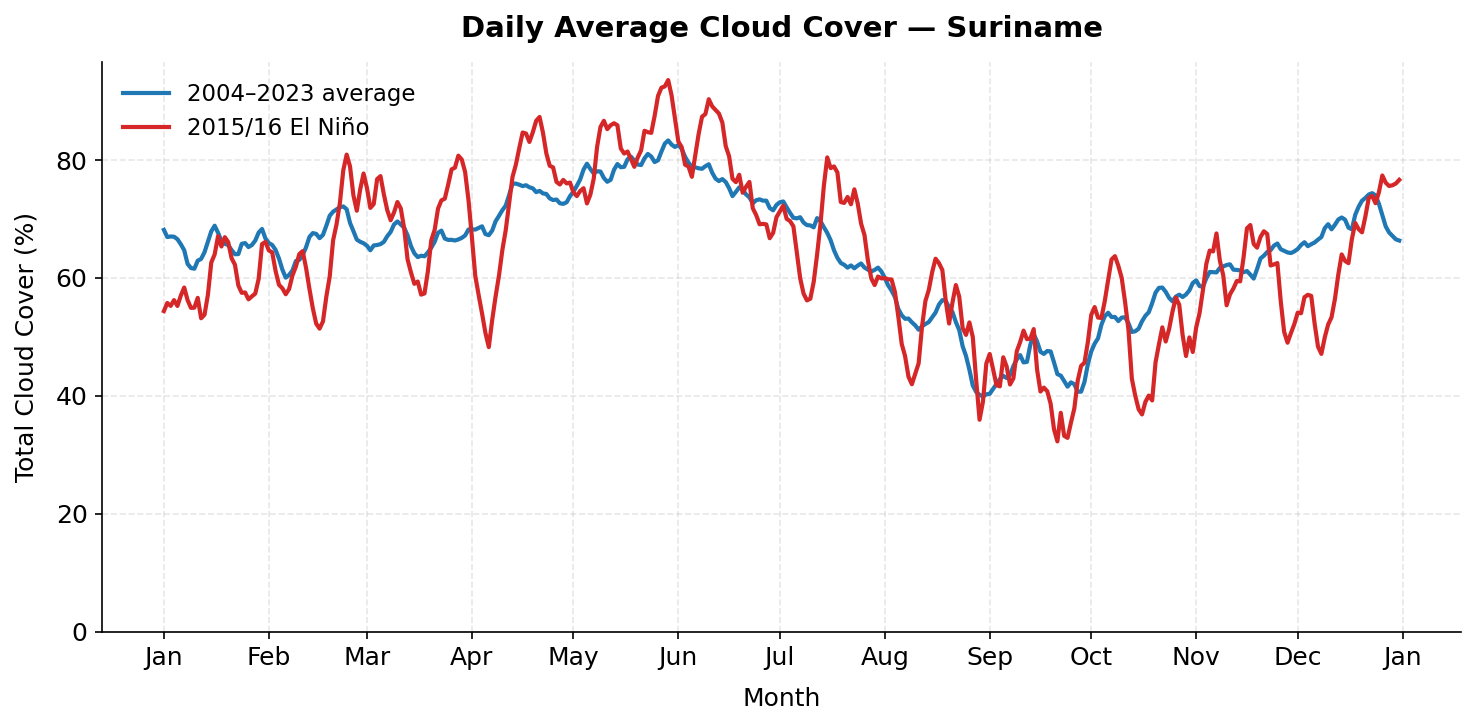

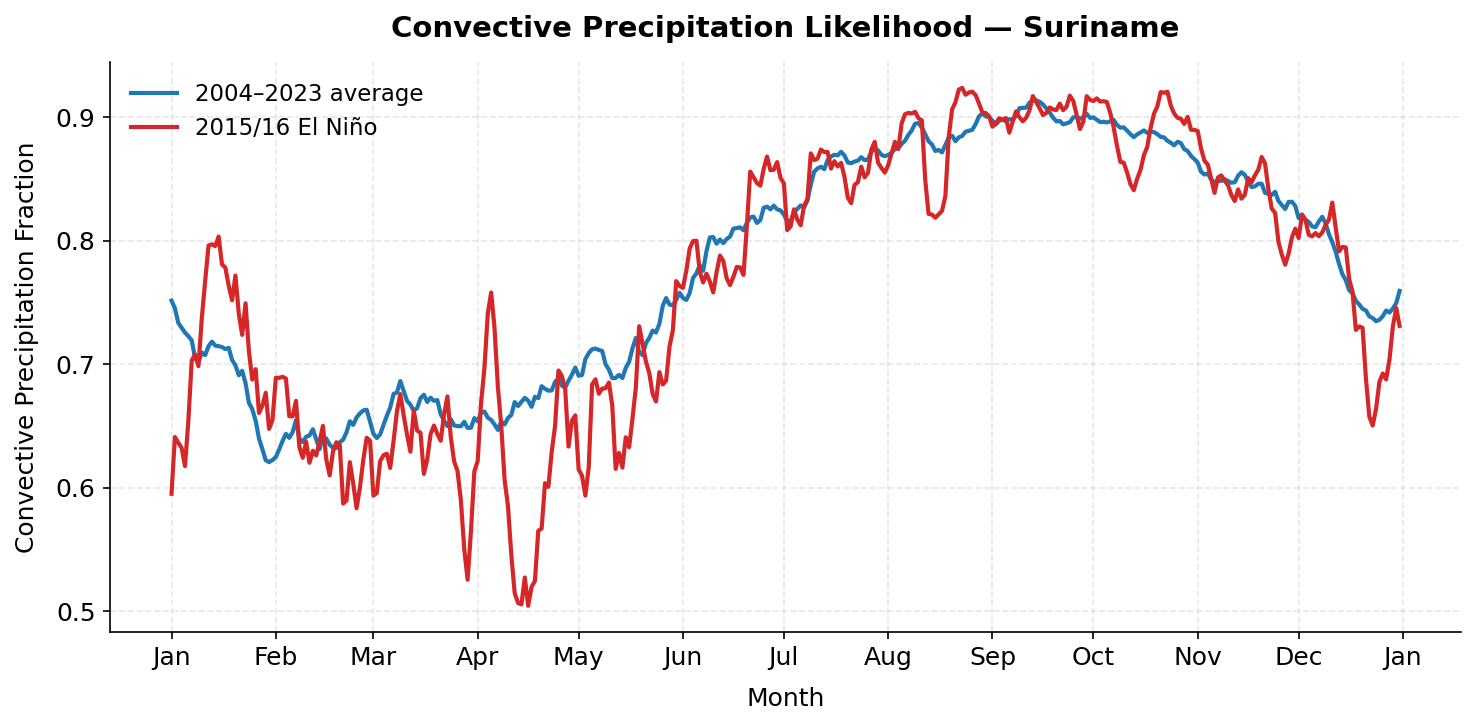

In [14]:
#Loading and Cleaning Data 
df = pd.read_csv("suriname_all_vars_2004_2023.csv")
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['month_day'] = df['date'].dt.strftime('%m-%d')

#Unit Conversion 
df['precip_mm'] = df['total_precipitation'] * 1000
df['convective_precip_mm'] = df['convective_precipitation'] * 1000
df['ssrd_MJ_m2'] = df['surface_solar_radiation_downwards'] / 1e6
df['cloud_cover_pct'] = df['total_cloud_cover'] * 100

# Convective precipitation fraction (guard against divide-by-zero)
df['convective_fraction'] = np.where(
    df['precip_mm'] > 0.01,
    df['convective_precip_mm'] / df['precip_mm'],
    np.nan
)

#Split into climatology (all 20 years) and El Niño (2015+2016)
climatology = df.groupby('month_day').agg({
    'precip_mm': 'mean',
    'ssrd_MJ_m2': 'mean',
    'cloud_cover_pct': 'mean',
    'convective_fraction': 'mean'
}).reset_index()

el_nino = df[df['year'].isin([2015, 2016])].groupby('month_day').agg({
    'precip_mm': 'mean',
    'ssrd_MJ_m2': 'mean',
    'cloud_cover_pct': 'mean',
    'convective_fraction': 'mean'
}).reset_index()

# Sort both by actual calendar order (month_day is a string, so sort via a dummy date)
climatology['sort_key'] = pd.to_datetime('2020-' + climatology['month_day'], format='%Y-%m-%d')
climatology = climatology.sort_values('sort_key')

el_nino['sort_key'] = pd.to_datetime('2020-' + el_nino['month_day'], format='%Y-%m-%d')
el_nino = el_nino.sort_values('sort_key')

#Plot guide
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 150
})

def smooth(series, window=7):
    return series.rolling(window=window, center=True, min_periods=1).mean()

def plot_variable(column, ylabel, title, filename, y_min=None):
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(climatology['sort_key'], smooth(climatology[column]),
            color='#1f77b4', linewidth=2, label='2004–2023 average')
    ax.plot(el_nino['sort_key'], smooth(el_nino[column]),
            color='#d62728', linewidth=2, label='2015/16 El Niño')

    ax.set_xlabel('Month', labelpad=8)
    ax.set_ylabel(ylabel, labelpad=8)
    ax.set_title(title, pad=12)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if y_min is not None:
        ax.set_ylim(bottom=y_min)

    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()

plot_variable('precip_mm', 'Precipitation (mm/day)',
              'Daily Average Rainfall — Suriname', 'plot_rainfall.png', y_min=0)

plot_variable('ssrd_MJ_m2', 'Solar Radiation (MJ/m²/day)',
              'Daily Average SW Radiation — Suriname', 'plot_solar_radiation.png', y_min=0)

plot_variable('cloud_cover_pct', 'Total Cloud Cover (%)',
              'Daily Average Cloud Cover — Suriname', 'plot_cloud_cover.png', y_min=0)

plot_variable('convective_fraction', 'Convective Precipitation Fraction',
              'Convective Precipitation Likelihood — Suriname', 'plot_convective_fraction.png')